Setup


In [7]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


Load the Iris dataset and visualize the dataset


In [16]:
iris = load_iris()

X = iris.data
Y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = Y

X.shape

'''
# Set up the figure size
plt.figure(figsize=(8, 6))

# Create scatter plots for each pair of features
for i in range(4):
    for j in range(i+1, 4):
        plt.subplot(2, 3, i*(3-i)//2 + j)
        
        # Create scatter plot
        scatter = plt.scatter(X[:, i], X[:, j], 
                            c=Y, 
                            cmap='viridis')
        
        # Add labels
        plt.xlabel(iris.feature_names[i])
        plt.ylabel(iris.feature_names[j])


plt.tight_layout()
plt.show()
'''


"\n# Set up the figure size\nplt.figure(figsize=(8, 6))\n\n# Create scatter plots for each pair of features\nfor i in range(4):\n    for j in range(i+1, 4):\n        plt.subplot(2, 3, i*(3-i)//2 + j)\n\n        # Create scatter plot\n        scatter = plt.scatter(X[:, i], X[:, j], \n                            c=Y, \n                            cmap='viridis')\n\n        # Add labels\n        plt.xlabel(iris.feature_names[i])\n        plt.ylabel(iris.feature_names[j])\n\n\nplt.tight_layout()\nplt.show()\n"

Split the dataset into training and testing sets

In [18]:
X_train , X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


Model : MLPClassifier

Activation: Logistic

Training the model

In [26]:
mlp = MLPClassifier(hidden_layer_sizes=(10 , 10,3), max_iter=1000, activation = 'logistic', solver ='adam', random_state = 42, verbose = True)

mlp.fit(X_train, Y_train)

Y_pred = mlp.predict(X_test)

print(f'Accuracy: {accuracy_score(Y_test, Y_pred) * 100} %')

Iteration 1, loss = 1.15582456
Iteration 2, loss = 1.15480933
Iteration 3, loss = 1.15380452
Iteration 4, loss = 1.15281028
Iteration 5, loss = 1.15182675
Iteration 6, loss = 1.15085408
Iteration 7, loss = 1.14989238
Iteration 8, loss = 1.14894177
Iteration 9, loss = 1.14800235
Iteration 10, loss = 1.14707421
Iteration 11, loss = 1.14615742
Iteration 12, loss = 1.14525205
Iteration 13, loss = 1.14435816
Iteration 14, loss = 1.14347578
Iteration 15, loss = 1.14260493
Iteration 16, loss = 1.14174565
Iteration 17, loss = 1.14089792
Iteration 18, loss = 1.14006175
Iteration 19, loss = 1.13923712
Iteration 20, loss = 1.13842401
Iteration 21, loss = 1.13762237
Iteration 22, loss = 1.13683217
Iteration 23, loss = 1.13605335
Iteration 24, loss = 1.13528584
Iteration 25, loss = 1.13452958
Iteration 26, loss = 1.13378448
Iteration 27, loss = 1.13305046
Iteration 28, loss = 1.13232742
Iteration 29, loss = 1.13161526
Iteration 30, loss = 1.13091387
Iteration 31, loss = 1.13022313
Iteration 32, los

c:\Users\longo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Evaluataion

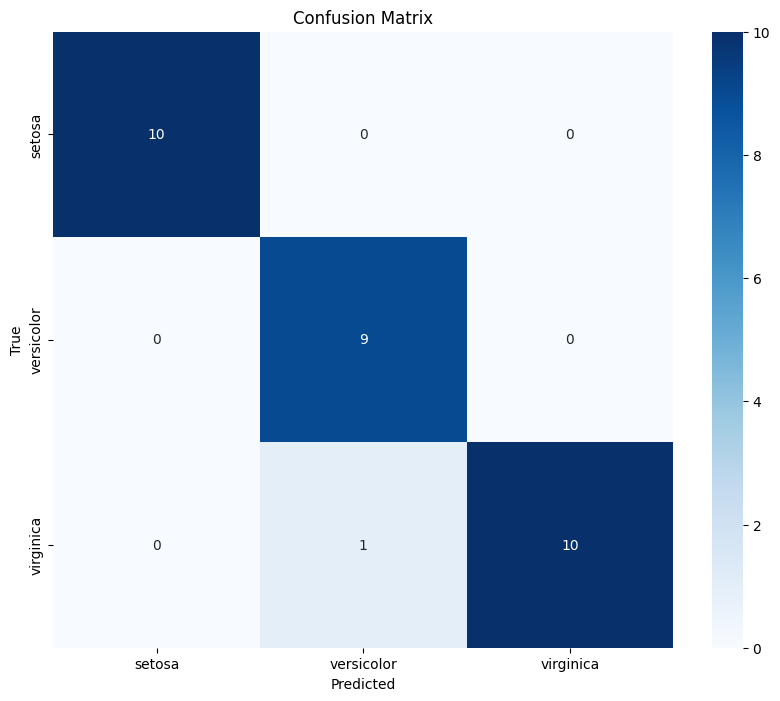


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      1.00      0.95         9
   virginica       1.00      0.91      0.95        11

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [28]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Create confusion matrix
cm = confusion_matrix(Y_test, Y_pred)

# Create figure and axes
plt.figure(figsize=(10, 8))

# Create heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)

# Add labels
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Print classification report for detailed metrics
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred, target_names=iris.target_names))

Hyperparameter Tuning

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best parameters: {'activation': 'logistic', 'hidden_layer_sizes': (10,), 'learning_rate_init': 0.001, 'max_iter': 1000, 'solver': 'adam'}
Best cross-validation score: 0.975

Test set accuracy with best model: 96.66666666666667 %


c:\Users\longo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


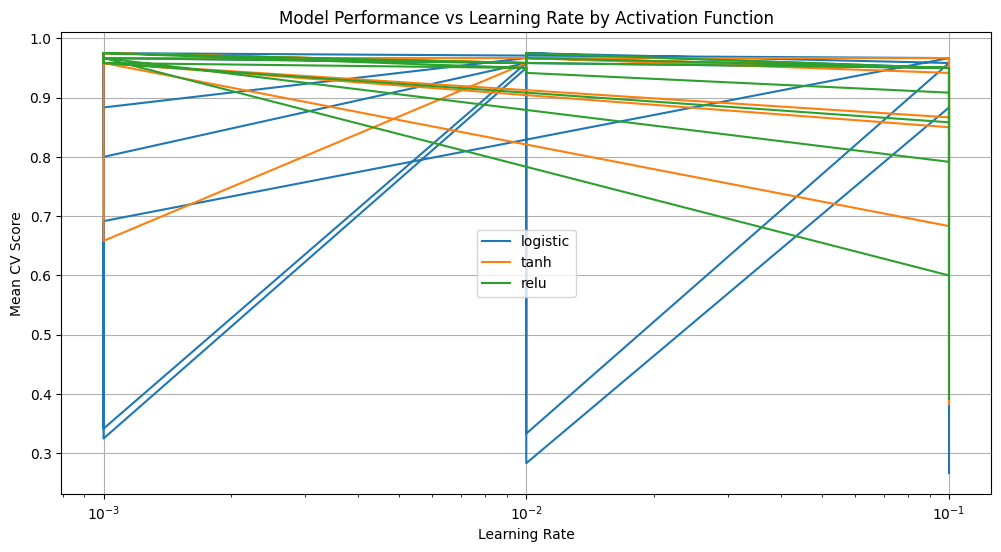

In [30]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'hidden_layer_sizes': [(10,), (20,), (10,10), (10,10,3)],
    'activation': ['logistic', 'tanh', 'relu'],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'max_iter': [1000],
    'solver': ['adam', 'sgd']
}

# Create MLPClassifier
mlp = MLPClassifier(random_state=42)

# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='accuracy',
    verbose=2
)

# Fit the grid search
grid_search.fit(X_train, Y_train)

# Print the best parameters and score
print("\nBest parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

# Use the best model for predictions
best_model = grid_search.best_estimator_
Y_pred = best_model.predict(X_test)

print(f"\nTest set accuracy with best model: {accuracy_score(Y_test, Y_pred) * 100} %")

# Visualize hyperparameter effects
results = pd.DataFrame(grid_search.cv_results_)
plt.figure(figsize=(12, 6))
for activation in param_grid['activation']:
    mask = results['param_activation'] == activation
    plt.plot(results[mask]['param_learning_rate_init'], 
             results[mask]['mean_test_score'], 
             label=activation)

plt.xscale('log')
plt.xlabel('Learning Rate')
plt.ylabel('Mean CV Score')
plt.title('Model Performance vs Learning Rate by Activation Function')
plt.legend()
plt.grid(True)
plt.show()